# Yolov11

### Imports and TensorBoard Setup

In [14]:
from pathlib import Path
import sys
import zipfile
import yaml
from ultralytics import YOLO, settings
import numpy as np  
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [15]:
%matplotlib inline

In [16]:
#Enable TensorBoard logging globally for Ultralytics
settings.update({"tensorboard": True})

### Preperation of dataset and extration of images

In [4]:
def extract_images_zip(dataset_root: Path, yolo_root: Path) -> None:
    #Look for any .zip files directly inside dataset_root
    zip_files = list(dataset_root.glob("*.zip"))

    if not zip_files:
        print(f"No zip files found in: {dataset_root}")
        print("Please make sure your images zip is in that folder.")
        return

    #If there are multiple zips, pick the first one
    zip_path = zip_files[0]
    print(f"Found zip file: {zip_path}")

    yolo_root.mkdir(parents=True, exist_ok=True)

    #Check if images already extracted
    images_dir = yolo_root / "images"
    if images_dir.exists():
        print(f"Images folder already extracted here: {images_dir}")
        print("Skipping extraction.")
        return

    print(f"Extracting {zip_path} to {yolo_root}:")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(yolo_root)

    print("Extraction finished.")

In [5]:
def fix_data_yaml(data_yaml_path: Path, yolo_root: Path) -> None:
    if not data_yaml_path.exists():
        raise FileNotFoundError(f"data.yaml not found at: {data_yaml_path}")

    print(f"Fixing data.yaml at: {data_yaml_path}")

    with open(data_yaml_path, "r") as f:
        data = yaml.safe_load(f)

    #Base path for YOLO
    data["path"] = str(yolo_root)

    images_dir = yolo_root / "images"
    train_dir = images_dir / "train"
    val_dir = images_dir / "val"
    test_dir = images_dir / "test"

    data["train"] = str(train_dir)
    data["val"] = str(val_dir)
    if test_dir.exists():
        data["test"] = str(test_dir)
    elif "test" in data:
        data.pop("test")

    with open(data_yaml_path, "w") as f:
        yaml.safe_dump(data, f)

    print("Updated data.yaml with these paths:")
    print(f"path: {data['path']}")
    print(f"train: {data['train']}")
    print(f"val: {data['val']}")
    if "test" in data:
        print(f"  test : {data['test']}")
    else:
        print("  test : (not set)")

    #Quick existence check
    print("\nChecking if these folders exist:")
    print(f"Train exists: {train_dir.exists()}")
    print(f"Val exists: {val_dir.exists()}")
    print(f"Test exists: {test_dir.exists()}")

In [6]:
def get_output_root() -> Path:
    try:
        return Path(__file__).resolve().parent
    except NameError:
        return Path.cwd()

In [7]:
def print_metric_summary(results) -> None:
    print("\nTraining metric summary:")

    results_dict = getattr(results, "results_dict", None)
    if results_dict is None:
        print("No results_dict found on results object. Raw results:")
        print(results)
        return

    for k in [
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)",
        "fitness",
    ]:
        if k in results_dict:
            print(f"{k}: {results_dict[k]:.4f}")
        else:
            print(f"{k}: (not available)")

### Model training

In [8]:
def main():
    dataset_root = Path(r"C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split")

    if not dataset_root.exists():
        print(f"Dataset root does not exist: {dataset_root}")
        sys.exit(1)

    # YOLO_COCO folder (where data.yaml is, and where we want images/labels)
    yolo_root = dataset_root / "YOLO" / "YOLO_COCO"
    data_yaml_path = yolo_root / "data.yaml"

    # Extract images from the .zip into YOLO_COCO
    extract_images_zip(dataset_root, yolo_root)

    # Fix data.yaml to point to the extracted folders in YOLO_COCO
    fix_data_yaml(data_yaml_path, yolo_root)

    # Decide where to save outputs 
    output_root = get_output_root()
    print(f"\nYOLO outputs will be saved under: {output_root}")

    # Train YOLOv11 for 100 epochs
    print("\nStarting training (100 epochs):")
    model = YOLO("yolo11s.pt")

    model.train(
        data=str(data_yaml_path),
        epochs=100,
        imgsz=640,
        project=str(output_root),
        name="TESTELLYN",
        task="detect",
        batch=-1,
        patience=20,
        exist_ok=True
    )

    print("\nTraining finished.")
    print(f"Check '{output_root / 'detect' / 'TESTELLYN'}' for your trained weights.")


if __name__ == "__main__":
    main()


Found zip file: C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\images.zip
Images folder already extracted here: C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images
Skipping extraction.
Fixing data.yaml at: C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\data.yaml
Updated data.yaml with these paths:
path: C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO
train: C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\train
val: C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\val
  test : C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\test

Checking if these folders exist:
Train exists: True
Val exists: True
Test exists: True

YOLO outputs will be saved under: c:\ari3129-cv-group-project

Starting training (100 epochs):
New https://pypi.org/project/ultralytics/8.4.7 available  Update with 'pip install -U ultralytics'
Ultra

train: Scanning C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\labels\train.cache... 485 images, 0 backgrounds, 0 corrupt: 100%|██████████| 485/485 [00:00<?, ?it/s]

train: C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\train\27213b1d-IMG_20251112_162818.jpg: corrupt JPEG restored and saved
train: C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\train\583b038b-IMG_20251112_162840.jpg: corrupt JPEG restored and saved
train: C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\train\a3c63c83-IMG_20251112_162857.jpg: corrupt JPEG restored and saved
train: C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\train\b8de4d86-IMG_20251112_162741.jpg: corrupt JPEG restored and saved
train: C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\train\f5697a6d-IMG_20251112_162900.jpg: corrupt JPEG restored and saved
AutoBatch: Computing optimal batch size for imgsz=640 at 60.0% CUDA memory utilization.
WARNING AutoBatch: intended for CUDA devices, using default batch-size 16
train: Fast image access  (ping: 0.10.0 ms, read


train: Scanning C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\labels\train.cache... 485 images, 0 backgrounds, 0 corrupt: 100%|██████████| 485/485 [00:00<?, ?it/s]

train: C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\train\27213b1d-IMG_20251112_162818.jpg: corrupt JPEG restored and saved
train: C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\train\583b038b-IMG_20251112_162840.jpg: corrupt JPEG restored and saved
train: C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\train\a3c63c83-IMG_20251112_162857.jpg: corrupt JPEG restored and saved
train: C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\train\b8de4d86-IMG_20251112_162741.jpg: corrupt JPEG restored and saved
train: C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\train\f5697a6d-IMG_20251112_162900.jpg: corrupt JPEG restored and saved
val: Fast image access  (ping: 0.50.3 ms, read: 794.1120.1 MB/s, size: 2467.2 KB)


...

    100/100         0G     0.4177     0.2956     0.8631          9        640: 100%|██████████| 31/31 [04:55<00:00,  9.53s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:29<00:00,  7.34s/it]

                   all        111        174       0.79      0.664      0.744       0.61



100 epochs completed in 9.215 hours.
Optimizer stripped from c:\ari3129-cv-group-project\TESTELLYN\weights\last.pt, 19.2MB
Optimizer stripped from c:\ari3129-cv-group-project\TESTELLYN\weights\best.pt, 19.2MB

Validating c:\ari3129-cv-group-project\TESTELLYN\weights\best.pt...
Ultralytics 8.3.132  Python-3.12.3 torch-2.9.1+cpu CPU (AMD Ryzen 7 6800HS Creator Edition)
YOLO11s summary (fused): 100 layers, 9,415,122 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:27<00:00,  6.99s/it]


                   all        111        174      0.837      0.655      0.754      0.623
Blind-Spot Mirror (Convex)         31         37      0.967      0.797      0.884      0.758
    No Entry (One Way)         35         41      0.835      0.634      0.776       0.65
No Through Road (T-Sign)         14         14       0.83        0.7      0.798      0.683
   Pedestrian Crossing         27         38      0.848      0.441      0.534      0.424
      Roundabout Ahead         11         14      0.721      0.556      0.647      0.485
                  Stop         30         30      0.822        0.8      0.885      0.736
Speed: 1.2ms preprocess, 103.9ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to c:\ari3129-cv-group-project\TESTELLYN

Training finished.
Check 'c:\ari3129-cv-group-project\detect\TESTELLYN' for your trained weights.


### Metrics and Evaluation

In [17]:
#Load trained model
model = YOLO(r"c:\ari3129-cv-group-project\TESTELLYN\weights\best.pt")

#Path to your data.yaml
YOLO_YAML_PATH = r"C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\data.yaml"


In [18]:
#Evaluate on test split
print("\nRunning full test evaluation:")
test_metrics = model.val(
    data=YOLO_YAML_PATH,
    split="test"       
)
print("\nTest Metrics Summary:")
print(test_metrics)



Running full test evaluation:
Ultralytics 8.3.132  Python-3.12.3 torch-2.9.1+cpu CPU (AMD Ryzen 7 6800HS Creator Edition)


YOLO11s summary (fused): 100 layers, 9,415,122 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 539.4270.5 MB/s, size: 1752.1 KB)


val: Scanning C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\labels\test.cache... 119 images, 0 backgrounds, 0 corrupt: 100%|██████████| 119/119 [00:00<?, ?it/s]
c:\Users\ellyn\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:38<00:00,  4.79s/it]


                   all        119        168      0.746      0.587      0.654      0.551
Blind-Spot Mirror (Convex)         29         33      0.958      0.689      0.801      0.728
    No Entry (One Way)         41         49      0.779      0.592      0.644      0.583
No Through Road (T-Sign)         12         12      0.533      0.583      0.558      0.476
   Pedestrian Crossing         20         25      0.789       0.36      0.545      0.414
      Roundabout Ahead         13         15      0.707      0.533      0.548      0.434
                  Stop         34         34       0.71      0.765       0.83      0.672
Speed: 2.5ms preprocess, 139.3ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to C:\Users\ellyn\runs\detect\val4

Test Metrics Summary:
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix objec

In [19]:
#Calculate mean metrics
metrics = test_metrics

print("Global metrics on test set\n")

print("mAP50-95:", metrics.box.map)      
print("mAP50:", metrics.box.map50)    
print("mAP75:", metrics.box.map75)   
print()

print("Mean Precision (over classes): ", metrics.box.p.mean())
print("Mean Recall (over classes): ", metrics.box.r.mean())
print()

names = metrics.names  
for idx, name in names.items():
    print(f'{name}:')
    print(f'Precision: {metrics.box.p[idx]:.3f}')
    print(f'Recall: {metrics.box.r[idx]:.3f}')
    print()


Global metrics on test set

mAP50-95: 0.5512052460719682
mAP50: 0.6543783993423183
mAP75: 0.6049521615849077

Mean Precision (over classes):  0.7461848396337759
Mean Recall (over classes):  0.5871098738348403

Blind-Spot Mirror (Convex):
Precision: 0.958
Recall: 0.689

No Entry (One Way):
Precision: 0.779
Recall: 0.592

No Through Road (T-Sign):
Precision: 0.533
Recall: 0.583

Pedestrian Crossing:
Precision: 0.789
Recall: 0.360

Roundabout Ahead:
Precision: 0.707
Recall: 0.533

Stop:
Precision: 0.710
Recall: 0.765



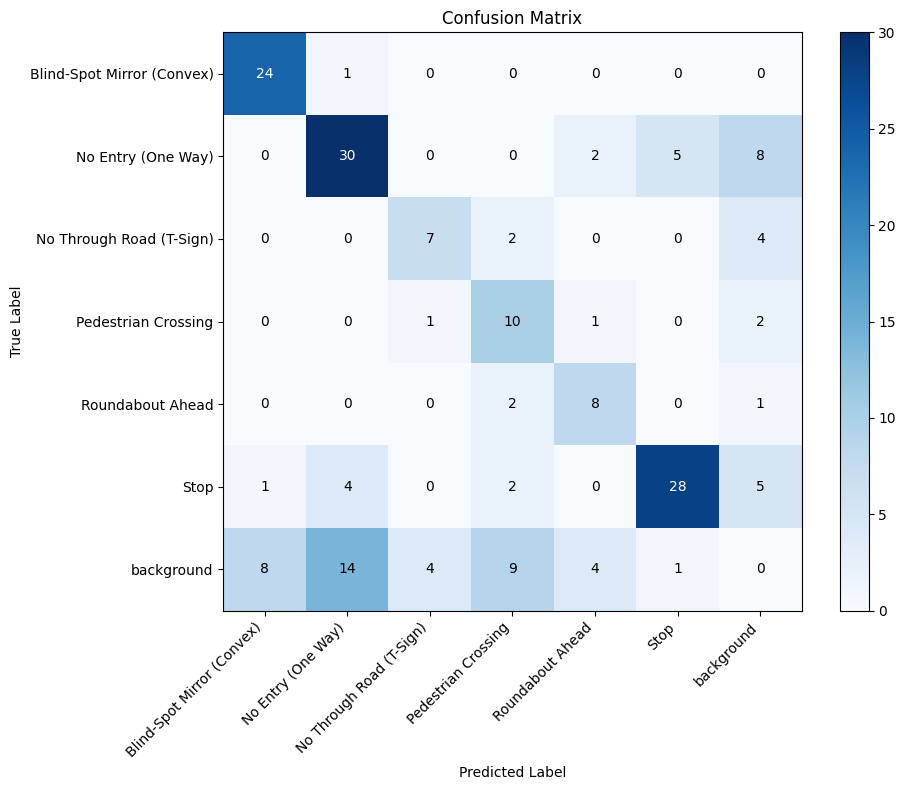

In [ ]:
#Compute Confusion Matrix
cm = test_metrics.confusion_matrix.matrix

names_dict = test_metrics.names
class_names = [names_dict[i] for i in range(len(names_dict))] + ["background"]

#Plotting Confusion Matrix
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, int(cm[i, j]),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=10
        )

plt.tight_layout()
plt.show()  

In [31]:
num_classes = len(names)

#Total ground truth objects (sum of all instances)
total_instances = cm.sum()

#Total correct detections (diagonal of confusion matrix)
total_correct = sum(cm[i][i] for i in range(num_classes))

#Total detections per class
pred_counts = cm.sum(axis=0)[:num_classes]

#Total ground-truth per class
gt_counts = cm.sum(axis=1)[:num_classes]    

print("Detection Statistics:")
print(f"Total Ground-Truth Objects: {total_instances}")
print(f"Total Correct Detections (TP): {total_correct}")
print(f"Overall Detection Accuracy: {total_correct / total_instances:.3f}\n")

print("Per-Class Statistics:\n")
for cls_id in range(num_classes):
    name = names_dict[cls_id]
    gt = int(gt_counts[cls_id])
    preds = int(pred_counts[cls_id])
    tp = int(cm[cls_id][cls_id])       

    print(f"{name}:")
    print(f"Ground Truth Count: {gt}")
    print(f"Predicted Count: {preds}")
    print(f"Correct Predictions: {tp}")
    print(f"Class Accuracy: {tp / gt:.3f}\n")


Detection Statistics:
Total Ground-Truth Objects: 188.0
Total Correct Detections (TP): 107.0
Overall Detection Accuracy: 0.569

Per-Class Statistics:

Blind-Spot Mirror (Convex):
Ground Truth Count: 25
Predicted Count: 33
Correct Predictions: 24
Class Accuracy: 0.960

No Entry (One Way):
Ground Truth Count: 45
Predicted Count: 49
Correct Predictions: 30
Class Accuracy: 0.667

No Through Road (T-Sign):
Ground Truth Count: 13
Predicted Count: 12
Correct Predictions: 7
Class Accuracy: 0.538

Pedestrian Crossing:
Ground Truth Count: 14
Predicted Count: 25
Correct Predictions: 10
Class Accuracy: 0.714

Roundabout Ahead:
Ground Truth Count: 11
Predicted Count: 15
Correct Predictions: 8
Class Accuracy: 0.727

Stop:
Ground Truth Count: 40
Predicted Count: 34
Correct Predictions: 28
Class Accuracy: 0.700



In [29]:
results_csv_path = Path(r"C:\ari3129-cv-group-project\TESTELLYN") / "results.csv"

if results_csv_path.exists():
    results_df = pd.read_csv(results_csv_path)
    print("Summary of Results:")
    print(results_df.head())
else:
    print("csv not found at that path.")

Summary of Results:
   epoch      time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1   448.109         0.85600         4.75186         1.03324   
1      2   867.888         0.86799         2.53038         1.00814   
2      3  1287.910         0.91896         1.91299         1.06083   
3      4  1727.960         0.91068         1.68598         1.07593   
4      5  2157.160         0.88052         1.45704         1.03979   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.51076            0.25115           0.30346   
1               0.51331            0.38757           0.41327   
2               0.65547            0.36481           0.44064   
3               0.56951            0.44243           0.44421   
4               0.56462            0.56104           0.56472   

   metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
0              0.23928       0.84802       3.51777       0.98963  0.000300   
1              0.3

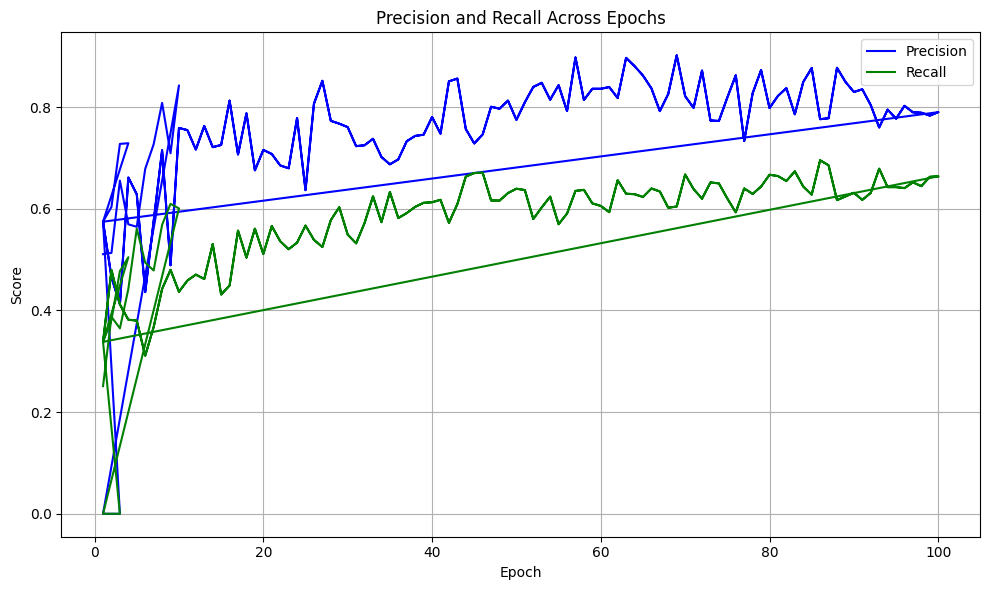

In [ ]:
#Plot Precision and Recall across epochs
plt.figure(figsize=(10, 6))

#Precision (blue)
plt.plot(
    results_df['epoch'],
    results_df['metrics/precision(B)'],
    color='blue',
    label='Precision'
)

#Recall (green)
plt.plot(
    results_df['epoch'],
    results_df['metrics/recall(B)'],
    color='green',
    label='Recall'
)

plt.title("Precision and Recall Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()